In [ ]:
import torch
import torch.nn as nn

In [ ]:
from torch.nn.modules.linear import Linear
class Model(nn.Module):

  def __init__(self,num_features) -> None:
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(num_features,10)
        ,nn.ReLU()
        ,nn.Linear(10,3)
        ,nn.ReLU()
        ,nn.Linear(3,1)
        ,nn.Sigmoid()
    )

  def forward(self,features):
    out = self.network(features)
    return out

In [ ]:
# Creating dataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'
features = torch.rand(10,5).to(device)

# create the model
model = Model(features.shape[1]).to(device)

# call model for forward pass
model(features)

tensor([[0.6230],
        [0.6259],
        [0.6490],
        [0.6198],
        [0.6315],
        [0.6404],
        [0.6292],
        [0.6293],
        [0.6337],
        [0.6449]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [ ]:
# show model weights
model.network[0].weight

Parameter containing:
tensor([[ 0.0566, -0.3188,  0.0981,  0.1384, -0.1418],
        [ 0.1593, -0.3832,  0.3716, -0.1933,  0.3647],
        [-0.1449,  0.2683,  0.1998,  0.3982, -0.0572],
        [ 0.3667,  0.4279, -0.2648,  0.0927,  0.1674],
        [ 0.1296,  0.0758,  0.3721, -0.2278,  0.3740],
        [ 0.3741,  0.2453, -0.3525,  0.3887,  0.0954],
        [-0.3838, -0.2327, -0.0478, -0.0516,  0.1705],
        [ 0.0675,  0.4351, -0.3041,  0.0537,  0.4414],
        [-0.3088, -0.3001,  0.2050, -0.3537, -0.1447],
        [-0.0729, -0.3944,  0.2237,  0.2165,  0.2211]], device='cuda:0',
       requires_grad=True)

In [ ]:
model.network[2].weight

Parameter containing:
tensor([[ 0.0531,  0.1121, -0.0104,  0.1181,  0.2742, -0.1284,  0.2128, -0.1585,
          0.0810, -0.2819],
        [-0.1710,  0.0377, -0.0076, -0.1506, -0.0366,  0.0321, -0.3090,  0.2122,
         -0.2872,  0.1502],
        [-0.0170,  0.0338, -0.3042, -0.2150, -0.2095,  0.0445, -0.0778,  0.0198,
         -0.1221, -0.0114]], device='cuda:0', requires_grad=True)

In [ ]:
model.network[0].bias

Parameter containing:
tensor([-0.1012, -0.0412, -0.3075, -0.2745,  0.4459, -0.1584,  0.1368, -0.3736,
        -0.1146, -0.3783], device='cuda:0', requires_grad=True)

In [ ]:
model.network[2].bias

Parameter containing:
tensor([-0.0251,  0.0247, -0.1905], device='cuda:0', requires_grad=True)

In [ ]:
from torchinfo import summary
summary(model,input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Sequential: 1-1                        [10, 1]                   --
│    └─Linear: 2-1                       [10, 10]                  60
│    └─ReLU: 2-2                         [10, 10]                  --
│    └─Linear: 2-3                       [10, 3]                   33
│    └─ReLU: 2-4                         [10, 3]                   --
│    └─Linear: 2-5                       [10, 1]                   4
│    └─Sigmoid: 2-6                      [10, 1]                   --
Total params: 97
Trainable params: 97
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
labels = torch.randint(0, 2, (10, 1), dtype=torch.float32).to(device)

# Make predictions
predictions = model(features)

# Convert probabilities to binary predictions
binary_predictions = (predictions >= 0.5).float()

# Calculate accuracy
correct_predictions = (binary_predictions == labels).sum().item()
total_predictions = labels.numel()
accuracy = correct_predictions / total_predictions

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7000


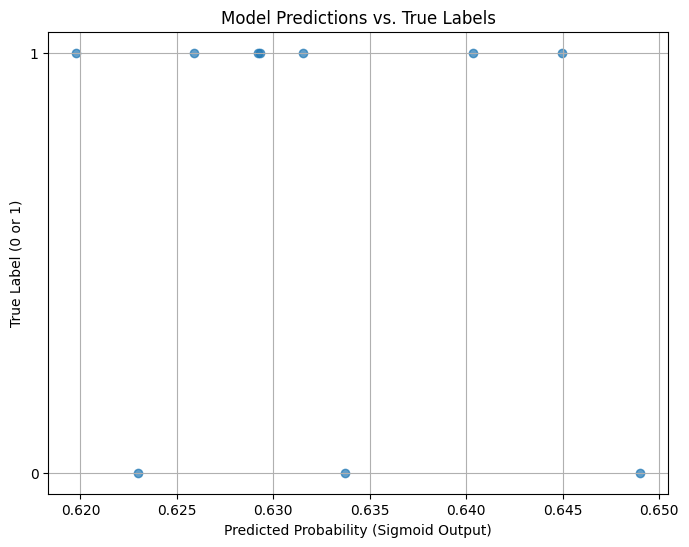

In [ ]:
import matplotlib.pyplot as plt

# Move predictions and labels to CPU for plotting if they are on GPU
predictions_cpu = predictions.detach().cpu().numpy()
labels_cpu = labels.cpu().numpy()

plt.figure(figsize=(8, 6))
plt.scatter(predictions_cpu, labels_cpu, alpha=0.7)
plt.title('Model Predictions vs. True Labels')
plt.xlabel('Predicted Probability (Sigmoid Output)')
plt.ylabel('True Label (0 or 1)')
plt.grid(True)
plt.yticks([0, 1]) # Ensure y-axis shows only 0 and 1
plt.show()